FOWT Farm Overview

Currently, the NREL 5MW wind turbine can be modeled on the OC3 Spar Type floating platform. Wind Speed, Wind Direction, Wave Speed, and Wave direction can all be used through the FOWT_spar_lookupto calculate the 6-dof through the FOWT_spar_lookup module under fowt in the offshore system.

Openfast was used to populate a lookup table with many simulations with varying environmental conditions (wind speed, direction, wave speed, wave direction). Linear interpolation is used for environemental other than those that were simulated. Since  waves naturally cause the floating turbine to rock back and forth, the average position value of the turbine over ~30 seconds, after any displacements from windspeed are taken into account.

The water depth of the lookup table used below is 320 meters. The mooring radius is 853.87 m, and 3 mooring lines are positioned 120 degrees apart.

Minimum wind speed is 4 m/s, minimum wave sig height is 1 m, maximum look up table wind speed is 22 m/s, maximum wave sig height is 7 m. Will be expanded for full 0-25 m/s range, 0-7 wave height. Wave period also to be added at some point in the future, currently, peak spectral period of layered wave is 10 seconds.

In [1]:
from wesl.optimizer.offshore_system.fowt.FOWT_spar_lookup import FOWT_Spar

fowt_example = FOWT_Spar()

print(fowt_example.solve_static_movement(wind_speed=12, wind_direction=60, wave_direction=20, wave_height=7))


(np.float64(-19.047985398252806), np.float64(-7.906454655061165), np.float64(-0.4483044149233526), np.float64(4.0836445607244976))


The function uses the Pywake coordinate system. Directions use degrees, where 0 degrees is from the North to the South, negative along the y axis. Wind speed is m/s, and wave_height is significant wave height in meters.

The returned values are: X displacement, Y displacement, Z displacement, and turbine tilt. Displacements are all meters, while tilt is in degrees. The other 2 degrees of freedom can also be accessed, but they are not currently used in any analysis.

We can visualize how the wind turbine is displaced under different wind speeds and directions.

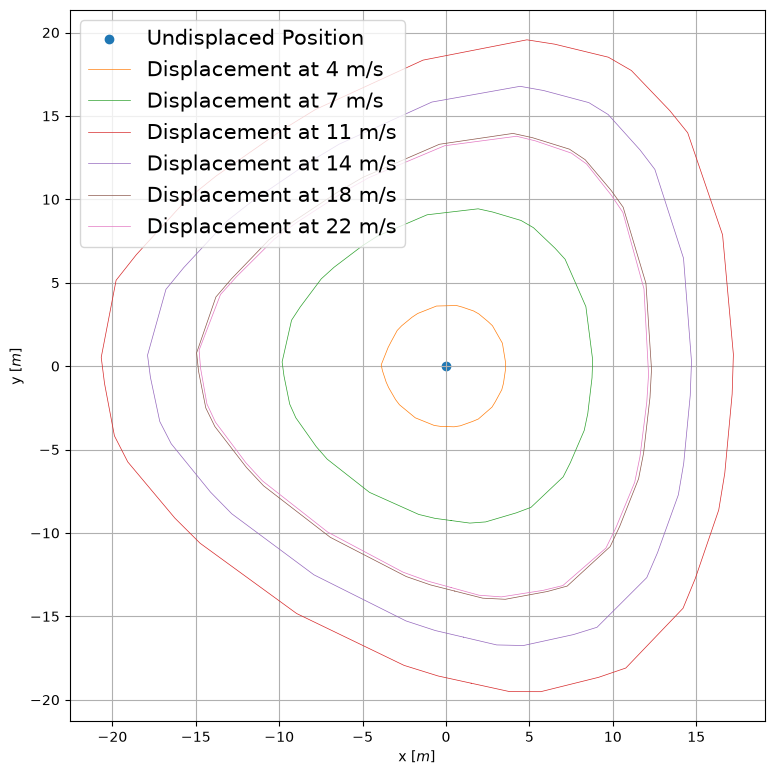

In [2]:
import numpy as np
import matplotlib.pyplot as plt

wind_speeds = np.linspace(4, 22, 6, endpoint=True, dtype = int)
wind_directions = np.linspace(0, 360, 60, endpoint=True, dtype = int)

displaced_x = np.zeros((len(wind_speeds), len(wind_directions)))
displaced_y = np.zeros((len(wind_speeds), len(wind_directions)))

for ws_index in range(len(wind_speeds)):
    for wd_index in range(len(wind_directions)):
        # print(wind_speeds[ws_index], wind_directions[wd_index])
        x_new, y_new, z_new, tilt_new = fowt_example.solve_static_movement(wind_speeds[ws_index],wind_directions[wd_index], wave_direction=0, wave_height=0)
        displaced_x[ws_index, wd_index] = x_new
        displaced_y[ws_index, wd_index] = y_new

# plot the displacements

plt.figure(figsize=(8,8))
plt.plot([0], [0])
plt.scatter(0,0, label = "Undisplaced Position")
for ws_index in range(len(wind_speeds)):
        x, y = displaced_x[ws_index,:], displaced_y[ws_index,:]
        # xr = np.vstack((xr, fowt_x[wt_index,0,ws_index]))
        # yr = np.vstack((yr, fowt_y[wt_index,0,ws_index]))
        color = ws_index / len(wind_speeds)# +0.1
        plt.plot(x, y,linewidth=0.5, label = f"Displacement at {wind_speeds[ws_index]} m/s")

plt.rcParams.update({'font.size': 15})
plt.xlabel('x [$m$]')
plt.ylabel('y [$m$]')
plt.legend()
plt.tight_layout()
plt.axis('equal')
plt.grid(True)


There is also an openMDAO component that can handle optimization of FOWT wind farms. The exact layout of the component is still WIP, however it is fully functional with non-gradient based optimizers. See the example below for usage.

/opt/anaconda3/envs/test_floating_wind_july26/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/test_floating_wind_july26/lib/python3.11/site-packages/openmdao/core/system.py:3628: OpenMDAOWarning:<class Group>: Constraint 'Spacing_Constraint.spacing_violation' requires one of arguments 'lower', 'upper', or 'equals' to be specified.
/opt/anaconda3/envs/test_floating_wind_july26/lib/python3.11/site-packages/openmdao/core/group.py:1197: DerivativesWarning:Constraints or objectives [floating_wind_farm.AEP] cannot be impacted by the design variables of the problem because no partials were defined for them in their parent component(s).


done
Entered compute fixedbottomcomponent


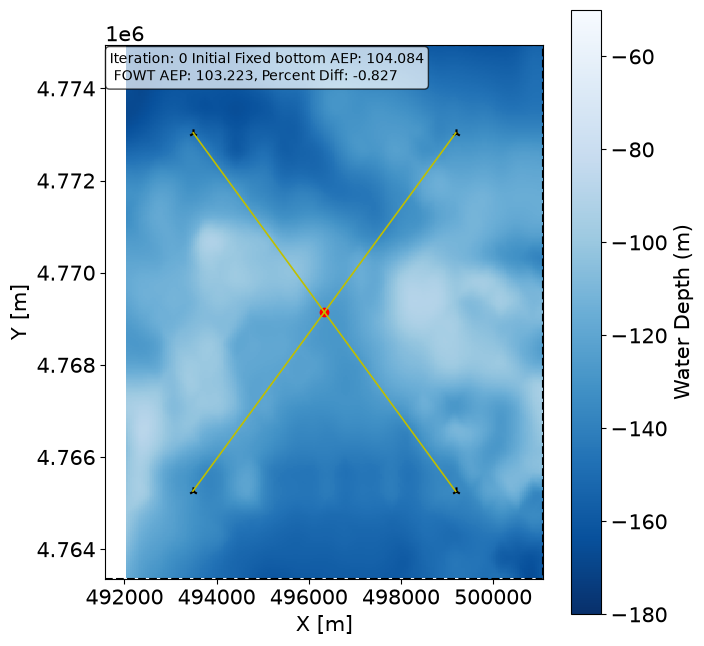

total time for compute cycle: 7.247830041917041 seconds
[5323.88306703 7395.48725171 9260.54556349 9260.54555972 7395.48325748
 5317.39696937]
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 6.885871374979615 seconds
[5323.88306703 7395.48725171 9260.54556349 9260.54555972 7395.48325748
 5317.39696937]
Entered compute fixedbottomcomponent


/opt/anaconda3/envs/test_floating_wind_july26/lib/python3.11/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 10
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


<Figure size 640x480 with 0 Axes>

...

total time for compute cycle: 7.368279499933124 seconds
[5324.70630677 7496.02808347 9201.71809674 9319.96135379 7296.12275097
 5318.32846935]
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 7.350131000159308 seconds
[5324.70630677 7396.03508583 9283.00844449 9239.95957505 7396.11452433
 5318.22113746]
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 7.3000471668783575 seconds
[5359.66567369 7394.95067325 9285.11283235 9283.82239102 7409.41787362
 5344.19917617]
Optimization FAILED.
Return from COBYLA because the objective function has been evaluated MAXFUN times.
-----------------------------------


In [3]:
# # WESL imports
from wesl.optimizer.constraints.wind_farm_constraints import BoundaryConstraint, PairWiseSpacing
from wesl.optimizer.offshore_system.wind_system import FloatingBottomWindFarm

# # WESL optimizer external dependencies
import numpy as np
import openmdao.api as om
from IPython.display import display

from pathlib import Path

 
# AEP Calculator: PyWake Dependencies
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from wesl.utils.plot import get_water_depth_map
from py_wake.literature.cumulative_sum import nrel5mw

from multiprocessing import freeze_support, set_start_method

from pyproj import Transformer

from py_wake.site._site import UniformWeibullSite

from wesl.optimizer.offshore_system.fowt.FOWT_spar_lookup import wave_site

class Maine_test(UniformWeibullSite): # Double-check: plot the wind rose
    def __init__(self, ti=0.07, shear=None):
        f = [8.37, 6.83, 5.38, 4.77, 4.10, 4.80,
            8.22, 13.29, 11.22, 10.14, 11.72, 11.16]
        a = [10.00, 10.29, 9.87, 10.22, 10.01, 9.09,
            11.19, 12.11, 10.65, 10.84, 11.68, 10.89]
        k = [2.241, 1.804, 1.849, 2.086, 1.871, 1.677,
            2.163, 2.836, 2.545, 2.405, 2.489, 2.587]
        UniformWeibullSite.__init__(self, np.array(f) / np.sum(f), a, k, ti=ti, shear=shear)
        self.name = "Maine Wind Farm"

# dummy site, get real data when possible

class test_site(wave_site):
    def __init__(self):
        wave_f = np.array([8.37, 6.83, 5.38, 4.77, 4.10, 4.80])
        wave_k = np.array([2.971, 2.971, 2.971, 2.971, 2.971, 2.971])
        wave_a = np.array([2.027, 2.027, 2.027, 2.027, 2.027, 2.027])
        wave_site.__init__(self, f=wave_f / sum(wave_f),a=wave_a,k=wave_k)

# IMPORTANT: make sure to set up code in function. This will make sure parallel processing in floating wind farm will function correctly.
# This is a by product of python multiprocessing and parrallelism

def main():
    test_wave_site = test_site()

    # Get turbine positions, depth map, etc like fixed bottom
    # Change n_turbine here, positions will be evaluated automatically
    # The exact method of aquiring x and y coordinates doesnt matter
    # just make sure they are euclidean

    n_turbine = 4

    min_lon, max_lon, min_lat, max_lat = -69.1, -68.85, 43.02, 43.15

    path = Path.cwd()

    water_depth_map_params = get_water_depth_map(water_depth_data=f"maine/maine_data.nc",
                                                min_lon = min_lon,
                                                max_lon = max_lon,
                                                min_lat = min_lat,
                                                max_lat = max_lat)
    #########################################################################################
    # Instantiating boundary and layout coordinates

    rows = int(np.ceil(np.sqrt(n_turbine)))
    columns =  int(np.ceil(n_turbine / rows))

    spacing = 0.035

    x_coordinates = np.linspace(min_lon+0.02, min_lon+0.02+spacing*columns, columns)
    y_coordinates = np.linspace(min_lat+0.02, min_lat+0.02+spacing*rows, rows,)


    x_coordinates, y_coordinates = np.meshgrid(x_coordinates, y_coordinates)

    x_coordinates = x_coordinates.flatten()
    y_coordinates = y_coordinates.flatten()

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)
    x_coordinates, y_coordinates = transformer.transform(x_coordinates, y_coordinates)

    x_coordinates = x_coordinates.flatten()
    y_coordinates = y_coordinates.flatten()

    x_coordinates = x_coordinates[:n_turbine]
    y_coordinates = y_coordinates[:n_turbine]

    # make boundary like usual

    x_boundary = [int(np.min(x_coordinates) - 1900), int(np.max(x_coordinates) + 1900)]
    y_boundary = [int(np.min(y_coordinates) - 1900), int(np.max(y_coordinates) + 1900)]

    boundary = np.array([
        [int(x_boundary[0]), int(y_boundary[0])],
        [int(x_boundary[1]), int(y_boundary[0])],
        [int(x_boundary[1]), int(y_boundary[1])],  
        [int(x_boundary[0]), int(y_boundary[1])]   
    ])

    # lookup model turbine is currently just nrel5mw
    wind_turbines = nrel5mw()
    site = Maine_test() 

    sim_res = Bastankhah_PorteAgel_2014(site,                 
                                        wind_turbines, 
                                        k=0.0324555)
    aep_init = sim_res(x_coordinates, y_coordinates).aep().sum() 

    prob = om.Problem()


    prob.model.add_subsystem('floating_wind_farm', 
                            FloatingBottomWindFarm(layout_coordinates = np.array([x_coordinates,
                                                                                y_coordinates]),
                                                sim_res = Bastankhah_PorteAgel_2014(site, 
                                                                                    wind_turbines, 
                                                                                    k=0.0324555), 
                                                boundary = boundary, 
                                                lon_grid_fine = water_depth_map_params[0],
                                                lat_grid_fine = water_depth_map_params[1],
                                                interpolated_elevation = water_depth_map_params[2],
                                                plot_lim = np.array(x_boundary + y_boundary),
                                                aep_init = aep_init,         
                                                num_cores = 1,               # num of cores for parallelizing  
                                                using_slurm = False,         # if using slurm, this will correctly parallelize, if this is incorrectly set, your optimization might be much slower 
                                                wave_site = test_wave_site   # use test wave site from before
                                                ),
                            promotes_inputs=['x', 'y'])

    prob.model.add_subsystem('Spacing_Constraint', 
                            PairWiseSpacing(n_turbines = n_turbine, 
                                            min_spacing = 3*wind_turbines.diameter()), 
                            promotes_inputs=['x', 'y'])

    prob.model.add_subsystem('Boundary_Constraint',
                            BoundaryConstraint(polygon_vertices = boundary,
                                                number_of_turbines = n_turbine),
                            promotes_inputs=['x','y']
    )

    # Driver setup
    prob.driver = om.ScipyOptimizeDriver(tol = 1e-9)
    prob.driver.options['optimizer'] = 'COBYLA'  # cobyla has best performance
    prob.driver.options['maxiter'] = 2
    prob.driver.options['disp'] = False

    # Input defaults
    prob.model.set_input_defaults('x', x_coordinates)
    prob.model.set_input_defaults('y', y_coordinates)

    # Design variables
    prob.model.add_design_var('x', 
                            lower=min(boundary[:,0]), 
                            upper=max(boundary[:,0]), 
                            scaler=0.01)

    prob.model.add_design_var('y', 
                            lower=min(boundary[:,1]), 
                            upper=max(boundary[:,1]), 
                            scaler=0.01)

    # Objective function
    prob.model.add_objective('floating_wind_farm.AEP',  scaler=0.01)

    # Setting constraints
    prob.model.add_constraint('Spacing_Constraint.spacing_violation', scaler=0.01)
    prob.model.add_constraint('Boundary_Constraint.boundary_cons', upper=0.0) 

    prob.setup()

    prob.run_driver()

    prob.cleanup()

# Run the program, the top two functions are important for parallelization.

if __name__ == '__main__':
    freeze_support()
    set_start_method('fork')    
    main()

